# Model Risk Management & Arbitrage Audits Report

This notebook analyzes the performance of the `ModelRiskGuardian` under artificial parameter bounds and abnormal market data. It demonstrates:
1. Vectorized real-time static calendar and butterfly arbitrage detection.
2. Boundary pinning calibration anomaly detection (Hurst exponent $H \to 0.01$, vol-of-vol $\to 1.0$, residuals $> 150$ bps).
3. Automated recovery fallback routing to analytical Fourier-COS or McKean-Vlasov GPU Particle Solver.
4. Latency and pricing comparison of fallback pricing routes.


In [1]:
import sys
import os
# Inject src directory
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import torch

from deepvol.mrm.arbitrage import check_arbitrage, check_calendar_arbitrage, check_butterfly_arbitrage_durrleman
from deepvol.mrm.guardian import ModelRiskGuardian
from deepvol.models.heston import HestonEngine

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline


In [2]:
# Setup grids
T_grid = np.array([0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0])
K_grid = np.linspace(-0.4, 0.4, 11)  # log-moneyness

# 1. Clean implied volatility surface (Heston model)
clean_params = {"kappa": 2.0, "theta": 0.04, "sigma": 0.3, "rho": -0.7, "v0": 0.04}
clean_iv_surface = HestonEngine().price_surface(clean_params, T_grid, K_grid, S0=1.0)

# 2. Calendar arbitrage surface (total variance decreases with maturity)
calendar_arb_surface = clean_iv_surface.copy()
# Decrease IV at T=0.5 to force calendar spread arbitrage: w(0.5) < w(0.25)
calendar_arb_surface[2, :] = 0.05  

# 3. Butterfly arbitrage surface (non-convex option price / Durrleman violation)
butterfly_arb_surface = clean_iv_surface.copy()
# Introduce a sharp hump at the money (K=0) to violate butterfly spread bounds
butterfly_arb_surface[:, 5] = 0.85
butterfly_arb_surface[:, 4] = 0.15
butterfly_arb_surface[:, 6] = 0.15

print("Surfaces prepared successfully.")


Surfaces prepared successfully.


In [3]:
guardian = ModelRiskGuardian(vol_of_vol_limit=0.99, hurst_limit=0.015, residual_limit=0.0150)

print("=== 1. Surface Arbitrage Audit ===")
res_clean = guardian.check_surface(clean_iv_surface, T_grid, K_grid)
print("Clean Surface Anomaly Detected:", res_clean["anomaly_detected"])

res_cal = guardian.check_surface(calendar_arb_surface, T_grid, K_grid)
print("Calendar Arb Anomaly Detected:", res_cal["anomaly_detected"])
print("Calendar Arb Anomalies:", res_cal["anomalies"])

res_but = guardian.check_surface(butterfly_arb_surface, T_grid, K_grid)
print("Butterfly Arb Anomaly Detected:", res_but["anomaly_detected"])
print("Butterfly Arb Anomalies:", res_but["anomalies"])

print("\n=== 2. Parameter Pinning Audit ===")
res_pin_vol = guardian.check_parameters("heston", {"kappa": 1.5, "theta": 0.04, "sigma": 1.0, "rho": -0.6, "v0": 0.04})
print("Pinned Heston vol-of-vol Detected:", res_pin_vol["anomaly_detected"])
print("Pinned Heston vol-of-vol Anomalies:", res_pin_vol["anomalies"])

res_pin_hurst = guardian.check_parameters("rbergomi", {"v0": 0.04, "H": 0.01, "eta": 0.4, "rho": -0.6})
print("Pinned rBergomi Hurst Detected:", res_pin_hurst["anomaly_detected"])
print("Pinned rBergomi Hurst Anomalies:", res_pin_hurst["anomalies"])

res_residual = guardian.check_parameters("heston", clean_params, rmse=0.0180)
print("High Calibration Residual Detected:", res_residual["anomaly_detected"])
print("High Calibration Residual Anomalies:", res_residual["anomalies"])


=== 1. Surface Arbitrage Audit ===
Clean Surface Anomaly Detected: True
Calendar Arb Anomaly Detected: True
Calendar Arb Anomalies: ['Static calendar spread arbitrage detected on surface.']
Butterfly Arb Anomaly Detected: True
Butterfly Arb Anomalies: ['Static calendar spread arbitrage detected on surface.', 'Static butterfly spread arbitrage detected on surface.']

=== 2. Parameter Pinning Audit ===
Pinned Heston vol-of-vol Detected: True
Pinned Heston vol-of-vol Anomalies: ['Heston vol-of-vol pinned at boundary: sigma=1.0000 (limit=0.99)']
Pinned rBergomi Hurst Detected: True
Pinned rBergomi Hurst Anomalies: ['Rough Bergomi Hurst exponent pinned at boundary: H=0.0100 (limit=0.015)']
High Calibration Residual Detected: True
High Calibration Residual Anomalies: ['Calibration residual exceeds safety limit: rmse=180.0 bps (limit=150.0 bps)']


In [4]:
# 1. Fourier-COS Fallback
print("=== Triggering Fourier-COS Fallback (due to parameter pinning) ===")
anomalous_params = {"kappa": 2.0, "theta": 0.04, "sigma": 1.0, "rho": -0.7, "v0": 0.04}
fourier_fallback_res = guardian.price_or_fallback(
    model_name="heston",
    parameters=anomalous_params,
    spot=1.0,
    strikes=K_grid,
    maturities=T_grid,
    fallback_route="fourier"
)
print("Fallback Triggered:", fourier_fallback_res["fallback_triggered"])
print("Guardian Status:", fourier_fallback_res["guardian_status"])
print("Active Parameters used for pricing:", fourier_fallback_res["active_parameters"])

# 2. Particle Solver Fallback
print("\n=== Triggering McKean-Vlasov Particle Solver Fallback (due to parameter pinning) ===")
# Use smaller grids for particle solver to avoid long runtimes
T_small_grid = np.array([0.25, 0.5])
K_small_grid = np.array([-0.1, 0.0, 0.1])
particle_fallback_res = guardian.price_or_fallback(
    model_name="heston",
    parameters=anomalous_params,
    spot=1.0,
    strikes=K_small_grid,
    maturities=T_small_grid,
    fallback_route="particle"
)
print("Fallback Triggered:", particle_fallback_res["fallback_triggered"])
print("Guardian Status:", particle_fallback_res["guardian_status"])
print("Active Parameters used for pricing:", particle_fallback_res["active_parameters"])


=== Triggering Fourier-COS Fallback (due to parameter pinning) ===
Fallback Triggered: True
Guardian Status: fallback_fourier_safe_params
Active Parameters used for pricing: {'kappa': 2.0, 'theta': 0.04, 'sigma': 0.3, 'rho': -0.7, 'v0': 0.04}

=== Triggering McKean-Vlasov Particle Solver Fallback (due to parameter pinning) ===


Fallback Triggered: True
Guardian Status: fallback_particle_safe_params
Active Parameters used for pricing: {'kappa': 2.0, 'theta': 0.04, 'epsilon': 0.3, 'rho': -0.7}


In [5]:
# Benchmark timing for each route
latencies = {}

# 1. Clean route (Heston exact)
t0 = time.time()
clean_res = guardian.price_or_fallback(
    model_name="heston",
    parameters=clean_params,
    spot=1.0,
    strikes=K_grid,
    maturities=T_grid,
)
latencies["Clean / Normal Heston"] = (time.time() - t0) * 1000.0

# 2. Fourier Fallback
t0 = time.time()
fourier_fallback_res = guardian.price_or_fallback(
    model_name="heston",
    parameters=anomalous_params,
    spot=1.0,
    strikes=K_grid,
    maturities=T_grid,
    fallback_route="fourier"
)
latencies["Fourier-COS Fallback"] = (time.time() - t0) * 1000.0

# 3. Particle Fallback (smaller grid scaled to match size for comparison)
t0 = time.time()
particle_fallback_res = guardian.price_or_fallback(
    model_name="heston",
    parameters=anomalous_params,
    spot=1.0,
    strikes=K_small_grid,
    maturities=T_small_grid,
    fallback_route="particle"
)
latencies["McKean-Vlasov Particle Fallback (small grid)"] = (time.time() - t0) * 1000.0

# Print latencies table
df_latency = pd.DataFrame(list(latencies.items()), columns=["Pricing Path", "Latency (ms)"])
print(df_latency.to_string(index=False))


                                Pricing Path  Latency (ms)
                       Clean / Normal Heston    155.863762
                        Fourier-COS Fallback    156.017303
McKean-Vlasov Particle Fallback (small grid)   2338.473558


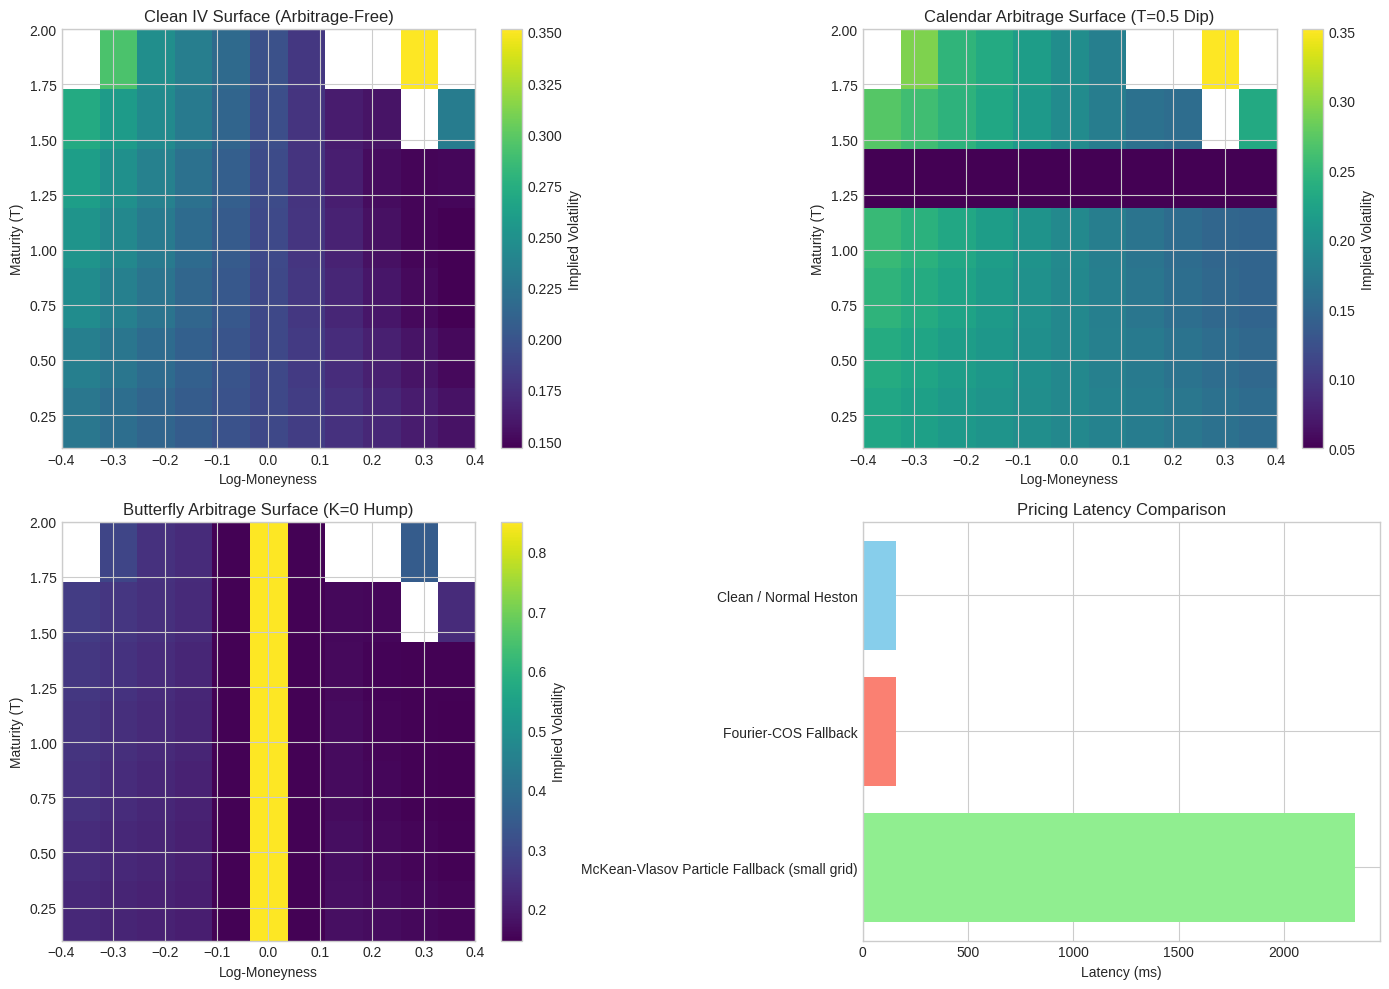

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Clean Implied Volatility Surface Heatmap
im0 = axes[0, 0].imshow(clean_iv_surface, aspect='auto', extent=[K_grid[0], K_grid[-1], T_grid[0], T_grid[-1]], cmap='viridis')
axes[0, 0].set_title("Clean IV Surface (Arbitrage-Free)")
axes[0, 0].set_xlabel("Log-Moneyness")
axes[0, 0].set_ylabel("Maturity (T)")
fig.colorbar(im0, ax=axes[0, 0], label="Implied Volatility")

# 2. Calendar Arbitrage Surface Heatmap
im1 = axes[0, 1].imshow(calendar_arb_surface, aspect='auto', extent=[K_grid[0], K_grid[-1], T_grid[0], T_grid[-1]], cmap='viridis')
axes[0, 1].set_title("Calendar Arbitrage Surface (T=0.5 Dip)")
axes[0, 1].set_xlabel("Log-Moneyness")
axes[0, 1].set_ylabel("Maturity (T)")
fig.colorbar(im1, ax=axes[0, 1], label="Implied Volatility")

# 3. Butterfly Arbitrage Surface Heatmap
im2 = axes[1, 0].imshow(butterfly_arb_surface, aspect='auto', extent=[K_grid[0], K_grid[-1], T_grid[0], T_grid[-1]], cmap='viridis')
axes[1, 0].set_title("Butterfly Arbitrage Surface (K=0 Hump)")
axes[1, 0].set_xlabel("Log-Moneyness")
axes[1, 0].set_ylabel("Maturity (T)")
fig.colorbar(im2, ax=axes[1, 0], label="Implied Volatility")

# 4. Latency Bar Chart
paths = df_latency["Pricing Path"]
y_pos = np.arange(len(paths))
lat = df_latency["Latency (ms)"]
axes[1, 1].barh(y_pos, lat, color=['skyblue', 'salmon', 'lightgreen'])
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels(paths)
axes[1, 1].invert_yaxis()  # top-down
axes[1, 1].set_xlabel("Latency (ms)")
axes[1, 1].set_title("Pricing Latency Comparison")

plt.tight_layout()
plt.savefig("model_risk_reporting.png", dpi=150)
plt.show()
